In [ ]:
!pip install imbalanced-learn xgboost --quiet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

print(" All imports done")

 All imports done


In [ ]:
df = pd.read_csv('/content/cs-training-clean.csv')

df.columns = [
    'target', 'util_rate', 'age', 'late_30_59',
    'debt_ratio', 'monthly_income', 'open_credits',
    'late_90', 'real_estate_loans', 'late_60_89', 'dependents'
]

df['monthly_income'].fillna(df['monthly_income'].median(), inplace=True)
df['dependents'].fillna(df['dependents'].median(), inplace=True)
df = df[df['age'] > 0]
df['util_rate'] = df['util_rate'].clip(upper=1.0)

print(f"✓ Loaded: {df.shape}")
print(f"✓ Target rate: {df['target'].mean():.2%}")

✓ Loaded: (21128, 11)
✓ Target rate: 6.44%


In [ ]:
# Feature Engineering

# 1. Debt to income ratio (if income is zero → set to 0)
df['debt_to_income'] = np.where(
    df['monthly_income'] > 0,
    df['debt_ratio'] / (df['monthly_income'] + 1),
    0
)

# 2. Total number of late payments
df['total_late'] = df['late_30_59'] + df['late_60_89'] + df['late_90']

# 3. Whether the person has any late payment history
df['has_late_history'] = (df['total_late'] > 0).astype(int)

# 4. Income per dependent
df['income_per_dependent'] = np.where(
    df['dependents'] > 0,
    df['monthly_income'] / df['dependents'],
    df['monthly_income']
)

# 5. Age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['young', 'middle', 'senior', 'elderly']
).astype(str)

# 6. High utilization flag
df['high_util'] = (df['util_rate'] > 0.7).astype(int)

print("✓ New features created:")
new_features = ['debt_to_income', 'total_late', 'has_late_history',
                'income_per_dependent', 'age_group', 'high_util']
print(df[new_features].describe().round(3))

✓ New features created:
       debt_to_income  total_late  has_late_history  income_per_dependent  \
count       21128.000   21128.000         21128.000             21128.000   
mean            1.961       0.861             0.205              5399.877   
std            39.986      11.646             0.404              5651.775   
min             0.000       0.000             0.000                 0.000   
25%             0.000       0.000             0.000              2859.250   
50%             0.000       0.000             0.000              5165.500   
75%             0.000       0.000             0.000              6000.000   
max          1747.000     294.000             1.000            251608.000   

       high_util  
count  21128.000  
mean       0.202  
std        0.402  
min        0.000  
25%        0.000  
50%        0.000  
75%        0.000  
max        1.000  


In [ ]:

#  Prepare X, y + Train/Test Split
feature_cols = [
    'util_rate', 'age', 'late_30_59', 'debt_ratio',
    'monthly_income', 'open_credits', 'late_90',
    'real_estate_loans', 'late_60_89', 'dependents',
    'debt_to_income', 'total_late', 'has_late_history',
    'income_per_dependent', 'high_util'
]

X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train target rate: {y_train.mean():.2%}")
print(f"Test  target rate: {y_test.mean():.2%}")

Train: (16902, 15) | Test: (4226, 15)
Train target rate: 6.44%
Test  target rate: 6.44%


In [ ]:

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"New train shape: {X_train_sm.shape}")

Before SMOTE: {0: 15814, 1: 1088}
After  SMOTE: {0: 15814, 1: 15814}
New train shape: (31628, 15)


In [ ]:

# Baseline: Logistic Regression
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train_sm, y_train_sm)

lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")

Logistic Regression ROC-AUC: 0.7958


In [ ]:

#  XGBoost v1

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost v1 ROC-AUC: {xgb_auc:.4f}")
print(f"Improvement over baseline: +{(xgb_auc - lr_auc):.4f}")

XGBoost v1 ROC-AUC: 0.7957
Improvement over baseline: +-0.0001


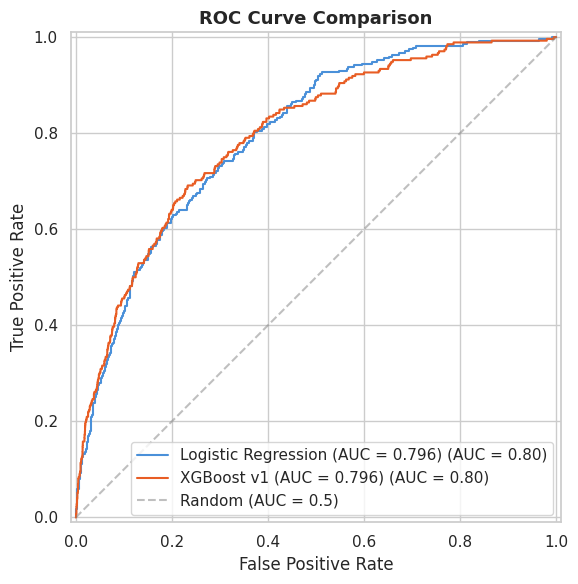

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, lr_proba,
    name=f'Logistic Regression (AUC = {lr_auc:.3f})',
    color='#4A90D9', ax=ax
)

RocCurveDisplay.from_predictions(
    y_test, xgb_proba,
    name=f'XGBoost v1 (AUC = {xgb_auc:.3f})',
    color='#E85D24', ax=ax
)

ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random (AUC = 0.5)')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

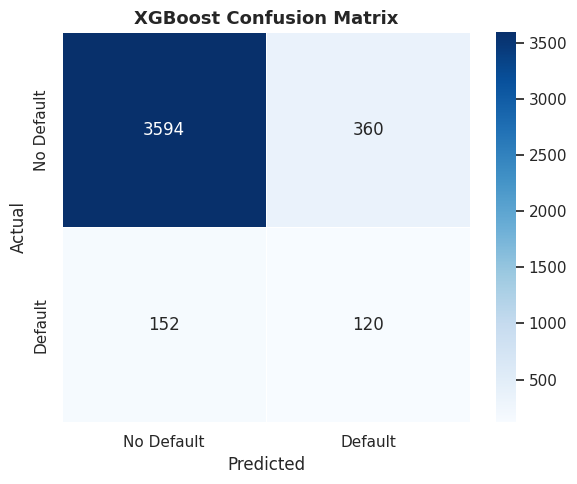


=== Classification Report ===
              precision    recall  f1-score   support

  No Default       0.96      0.91      0.93      3954
     Default       0.25      0.44      0.32       272

    accuracy                           0.88      4226
   macro avg       0.60      0.68      0.63      4226
weighted avg       0.91      0.88      0.89      4226



In [ ]:

xgb_preds = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, xgb_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default'],
    linewidths=0.5
)
ax.set_title('XGBoost Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, xgb_preds,
      target_names=['No Default', 'Default']))

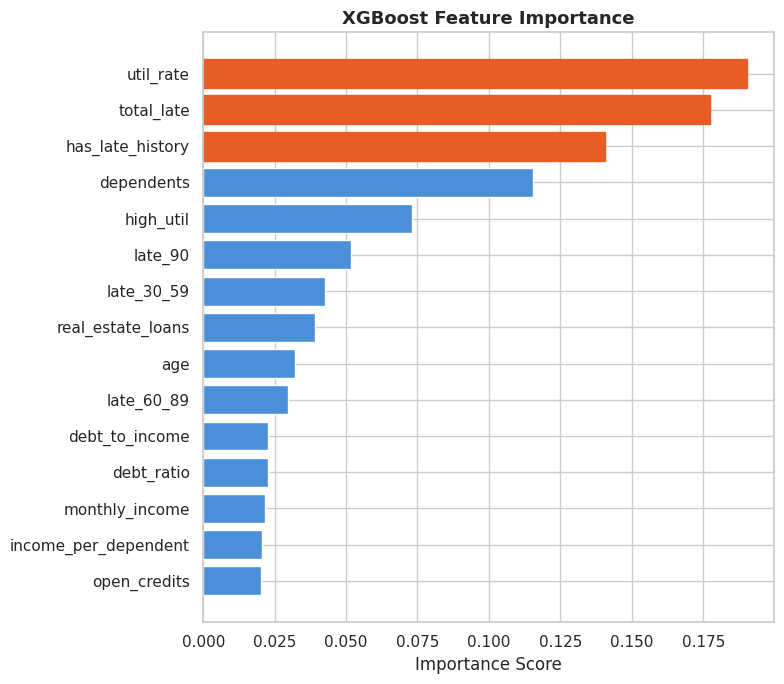


Top 5 features:
         feature  importance
       high_util    0.073117
      dependents    0.115286
has_late_history    0.140463
      total_late    0.177462
       util_rate    0.190266


In [ ]:

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color='#4A90D9', edgecolor='white')

for i in range(-3, 0):
    bars[i].set_color('#E85D24')

ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(importance_df.tail(5)[['feature','importance']].to_string(index=False))

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold: {[f'{s:.4f}' for s in cv_scores]}")

CV ROC-AUC: 0.8429 ± 0.0158
Per fold: ['0.8356', '0.8437', '0.8647', '0.8524', '0.8179']


In [ ]:

import pickle, json

# Save model
with open('xgboost_v1.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("✓ xgboost_v1.pkl saved")
print("✓ feature_cols.json saved")
print(f"\nFinal ROC-AUC on test set: {xgb_auc:.4f}")

✓ xgboost_v1.pkl saved
✓ feature_cols.json saved

Final ROC-AUC on test set: 0.7957
